In [69]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [70]:
df=pd.read_excel('WHR26_Data_Figure_2.1.xlsx')

In [71]:
df.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


In [72]:
df.tail()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
2111,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2112,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2114,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2115,2011,156,Togo,3.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   object 
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by

In [74]:
df.columns

Index(['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)',
       'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita',
       'Explained by: Social support', 'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')

In [75]:
(df.isnull().mean() * 100).sort_values(ascending=False)

Dystopia + residual                           52.126654
Explained by: Healthy life expectancy         51.984877
Explained by: Freedom to make life choices    51.937618
Explained by: Perceptions of corruption       51.890359
Explained by: Log GDP per capita              51.843100
Explained by: Social support                  51.843100
Explained by: Generosity                      51.843100
Lower whisker                                 51.701323
Upper whisker                                 51.701323
Year                                           0.000000
Rank                                           0.000000
Country name                                   0.000000
Life evaluation (3-year average)               0.000000
dtype: float64

In [76]:
feature_cols = [
    'Explained by: Log GDP per capita',
    'Explained by: Social support',
    'Explained by: Healthy life expectancy',
    'Explained by: Freedom to make life choices',
    'Explained by: Generosity',
    'Explained by: Perceptions of corruption',
    'Dystopia + residual'
]

df = df.dropna(subset=feature_cols, how='all')

In [77]:
for col in feature_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [78]:
df['Lower whisker'].fillna(df['Lower whisker'].median(), inplace=True)
df['Upper whisker'].fillna(df['Upper whisker'].median(), inplace=True)

In [79]:
df = df.drop(columns=['Lower whisker', 'Upper whisker'])

In [80]:
df.isnull().sum()

Year                                          0
Rank                                          0
Country name                                  0
Life evaluation (3-year average)              0
Explained by: Log GDP per capita              0
Explained by: Social support                  0
Explained by: Healthy life expectancy         0
Explained by: Freedom to make life choices    0
Explained by: Generosity                      0
Explained by: Perceptions of corruption       0
Dystopia + residual                           0
dtype: int64

<b> RQ1  What factors most strongly influence happiness globally?

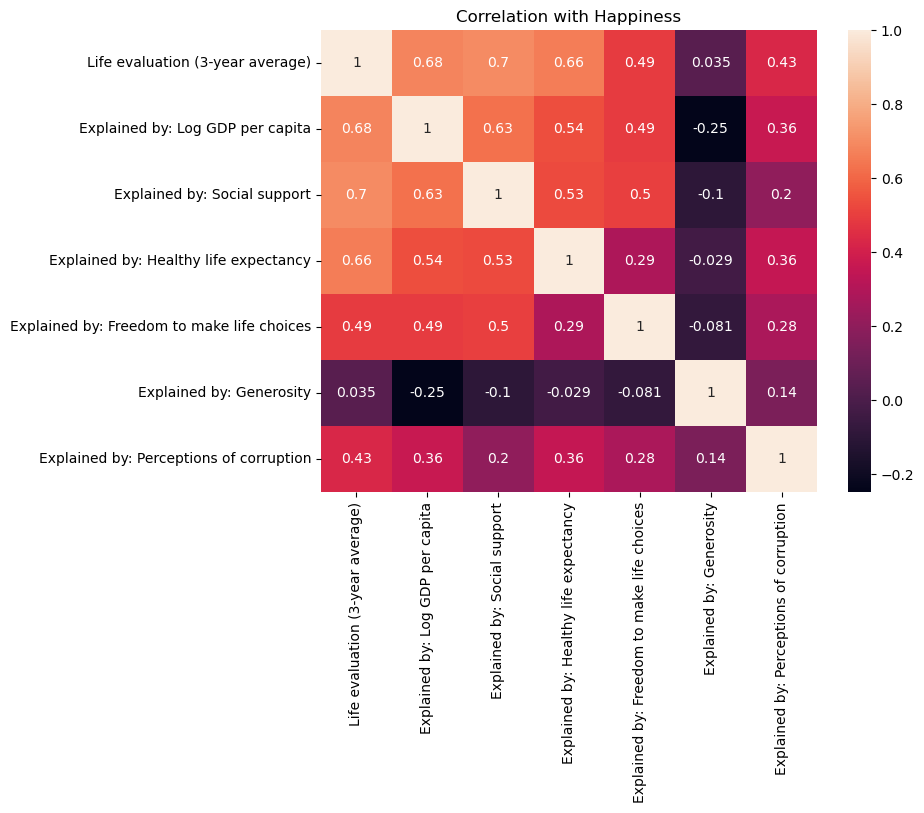

In [81]:
cols = [
    'Life evaluation (3-year average)',
    'Explained by: Log GDP per capita',
    'Explained by: Social support',
    'Explained by: Healthy life expectancy',
    'Explained by: Freedom to make life choices',
    'Explained by: Generosity',
    'Explained by: Perceptions of corruption'
]

corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation with Happiness")
plt.show()

In [82]:
corr_target = corr['Life evaluation (3-year average)'].sort_values(ascending=False)
print(corr_target)

Life evaluation (3-year average)              1.000000
Explained by: Social support                  0.701408
Explained by: Log GDP per capita              0.681186
Explained by: Healthy life expectancy         0.658859
Explained by: Freedom to make life choices    0.490963
Explained by: Perceptions of corruption       0.426029
Explained by: Generosity                      0.035323
Name: Life evaluation (3-year average), dtype: float64


<b> RQ2 Has global happiness improved or declined over time?

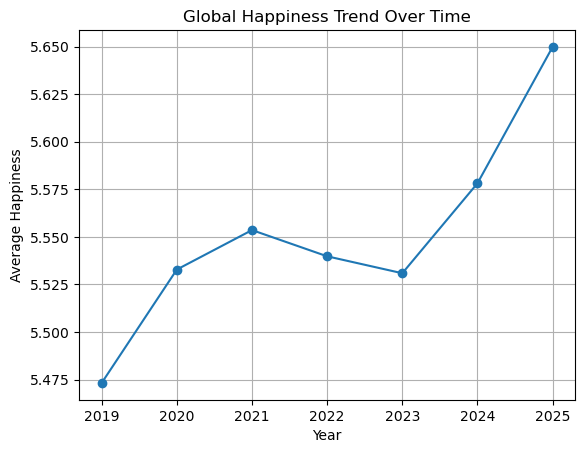

In [83]:
trend = df.groupby('Year')['Life evaluation (3-year average)'].mean()
plt.figure()
trend.plot(marker='o')
plt.title("Global Happiness Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Happiness")
plt.grid()
plt.show()

<b> RQ3 Which countries consistently rank in the top 10—and why?

In [84]:
top10 = df[df['Rank'] <= 10]

top_countries = top10['Country name'].value_counts()
print(top_countries.head(10))

top_analysis = top10.groupby('Country name')[
    [
        'Life evaluation (3-year average)',
        'Explained by: Log GDP per capita',
        'Explained by: Social support',
        'Explained by: Healthy life expectancy',
        'Explained by: Freedom to make life choices'
    ]
].mean()
print(top_analysis.sort_values(by='Life evaluation (3-year average)', ascending=False))

Finland        7
Iceland        7
Denmark        7
Sweden         7
Norway         7
Netherlands    7
Luxembourg     7
Switzerland    6
Israel         5
New Zealand    4
Name: Country name, dtype: int64
              Life evaluation (3-year average)  \
Country name                                     
Finland                               7.788100   
Denmark                               7.590086   
Iceland                               7.532214   
Netherlands                           7.368414   
Costa Rica                            7.356500   
Sweden                                7.348500   
Norway                                7.338000   
Switzerland                           7.326817   
Israel                                7.319800   
Austria                               7.281100   
New Zealand                           7.224900   
Luxembourg                            7.214357   
Australia                             7.057000   
Mexico                                6.979000 

<b> RQ4 Are richer countries always happier?

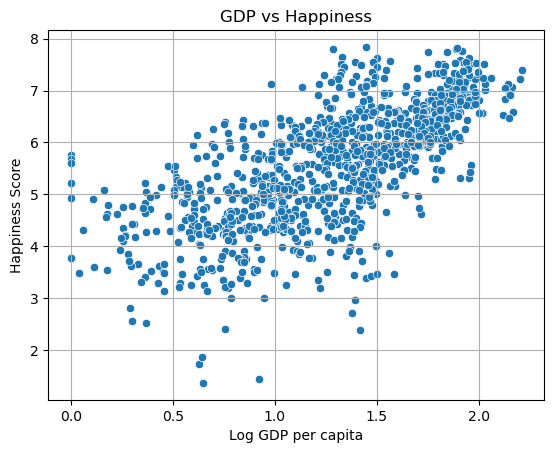

In [85]:
plt.figure()
sns.scatterplot(
    data=df,
    x='Explained by: Log GDP per capita',
    y='Life evaluation (3-year average)'
)

plt.title("GDP vs Happiness")
plt.xlabel("Log GDP per capita")
plt.ylabel("Happiness Score")
plt.grid()
plt.show()

In [86]:
corr_gdp = df['Explained by: Log GDP per capita'].corr(
    df['Life evaluation (3-year average)']
)
print("Correlation between GDP and Happiness:", corr_gdp)

Correlation between GDP and Happiness: 0.6811856757441995


<b> RQ5 Which region offers the best balanced life?

               Life evaluation (3-year average)  Explained by: Social support  \
Region                                                                          
Asia                                   4.026329                      0.607886   
Europe                                 6.930114                      1.336506   
North America                          6.860943                      1.371255   
Oceania                                7.087114                      1.408307   
South America                          6.360514                      1.255066   

               Explained by: Healthy life expectancy  \
Region                                                 
Asia                                        0.382510   
Europe                                      0.771159   
North America                               0.613517   
Oceania                                     0.802373   
South America                               0.553588   

               Explained by: Freedom to

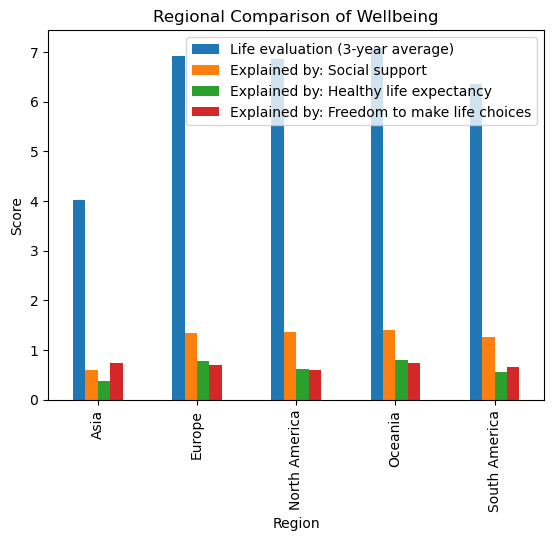

In [87]:
region_map = {
    'India': 'Asia',
    'United States': 'North America',
    'Germany': 'Europe',
    'Brazil': 'South America',
    'Australia': 'Oceania'
}
df['Region'] = df['Country name'].map(region_map)
region_analysis = df.groupby('Region')[
    [
        'Life evaluation (3-year average)',
        'Explained by: Social support',
        'Explained by: Healthy life expectancy',
        'Explained by: Freedom to make life choices'
    ]
].mean()
print(region_analysis)
region_analysis.plot(kind='bar')
plt.title("Regional Comparison of Wellbeing")
plt.ylabel("Score")
plt.show()

<b> RQ6 Which is the best place to stay?

In [88]:
df['Best Place Score'] = (
    df['Life evaluation (3-year average)'] * 0.4 +
    df['Explained by: Social support'] * 0.2 +
    df['Explained by: Healthy life expectancy'] * 0.2 +
    df['Explained by: Freedom to make life choices'] * 0.2
)
best_places = df.groupby('Country name')['Best Place Score'].mean().sort_values(ascending=False)
print(best_places.head(10))

Country name
Finland        3.735900
Denmark        3.649515
Iceland        3.649154
Norway         3.553184
Sweden         3.551003
Netherlands    3.536107
Switzerland    3.509734
Israel         3.481177
Luxembourg     3.467632
New Zealand    3.448724
Name: Best Place Score, dtype: float64


<b> RQ7 Which countries break the rule?

In [89]:
outliers = df[
    (df['Explained by: Log GDP per capita'] > df['Explained by: Log GDP per capita'].quantile(0.75)) &
    (df['Life evaluation (3-year average)'] < df['Life evaluation (3-year average)'].quantile(0.25))
]
print(outliers[['Country name', 'Year', 'Life evaluation (3-year average)', 'Explained by: Log GDP per capita']])

    Country name  Year  Life evaluation (3-year average)  \
542      Türkiye  2022                             4.614   

     Explained by: Log GDP per capita  
542                             1.714  


In [90]:
positive_outliers = df[
    (df['Explained by: Log GDP per capita'] < df['Explained by: Log GDP per capita'].quantile(0.25)) &
    (df['Life evaluation (3-year average)'] > df['Life evaluation (3-year average)'].quantile(0.75))
]
print(positive_outliers[['Country name', 'Year', 'Life evaluation (3-year average)']])

    Country name  Year  Life evaluation (3-year average)
749    Guatemala  2020                            6.4350
897    Guatemala  2019                            6.3989


<b> RQ8 Which continents offer better life evaluation?

In [91]:
df.groupby('Region')['Life evaluation (3-year average)'].mean().sort_values()

Region
Asia             4.026329
South America    6.360514
North America    6.860943
Europe           6.930114
Oceania          7.087114
Name: Life evaluation (3-year average), dtype: float64

<b> RQ9 Which countries are happy vs volatile?

In [92]:
stability = df.groupby('Country name')['Life evaluation (3-year average)'].std()
print(stability.sort_values().head(10))  # most stable
print(stability.sort_values(ascending=False).head(10))  # most volatile

Country name
Belize          0.000000
Oman            0.000000
Swaziland       0.000071
Burundi         0.000212
Maldives        0.000283
Iceland         0.019455
Botswana        0.033153
North Cyprus    0.039694
Finland         0.041187
Belgium         0.042810
Name: Life evaluation (3-year average), dtype: float64
Country name
Lebanon        0.920849
Bangladesh     0.530834
Afghanistan    0.510772
Viet Nam       0.447491
DR Congo       0.446012
Comoros        0.408072
Pakistan       0.400176
Lesotho        0.397232
Eswatini       0.374293
Venezuela      0.370740
Name: Life evaluation (3-year average), dtype: float64


<b> RQ10 What factors consider one nation to be happy or not?

In [93]:
from sklearn.ensemble import RandomForestRegressor
features = df[feature_cols]
target = df['Life evaluation (3-year average)']
model = RandomForestRegressor()
model.fit(features, target)
importance = pd.Series(model.feature_importances_, index=feature_cols)
print(importance.sort_values(ascending=False))

Explained by: Social support                  0.277474
Dystopia + residual                           0.210642
Explained by: Healthy life expectancy         0.208059
Explained by: Log GDP per capita              0.145015
Explained by: Perceptions of corruption       0.089879
Explained by: Freedom to make life choices    0.053453
Explained by: Generosity                      0.015479
dtype: float64
